In [1]:
#importing libraries
import ast 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Ezekiel\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Apr  2 10:40:05 2026).


In [7]:
df_skills = df.copy()
df_skills= df_skills.explode('job_skills')
df_skills= df_skills.groupby(['job_title_short','job_skills']).size()
df_skills= df_skills.reset_index(name='skills_count')
df_skills.sort_values(by='skills_count', ascending=False, inplace=True)

df_skills

,job_title_short,job_skills,skills_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


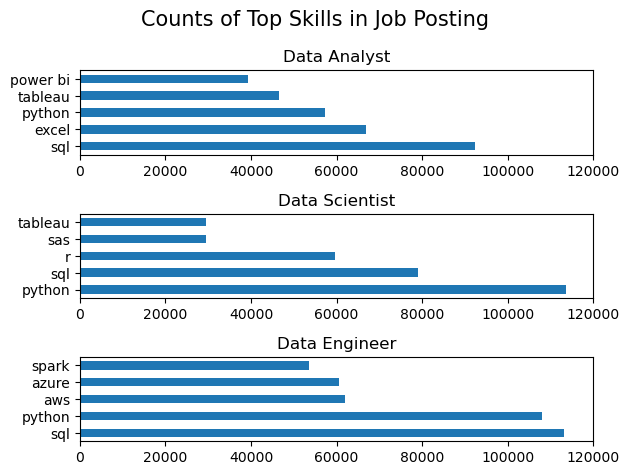

In [36]:
job_titles= ['Data Analyst','Data Scientist','Data Engineer']

fig, ax= plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot= df_skills[df_skills['job_title_short']== job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills', y='skills_count', ax= ax[i], title=job_title)
    ax[i].invert_xaxis
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000)

fig.suptitle('Counts of Top Skills in Job Posting', fontsize= 15)
fig.tight_layout()

In [25]:
df_skills_final

,job_title_short,job_skills,skills_count
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
686,Data Engineer,aws,62049
687,Data Engineer,azure,60674
860,Data Engineer,spark,53656
